# Feature Engineering Avanzado en Senales Fisiologicas

## FatigueSet - Analisis Profesional Nivel TFG

Feature engineering completo, reproducible y listo para produccion

In [6]:
# SETUP
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import random
np.random.seed(42)
random.seed(42)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.signal import welch
from scipy.stats import entropy, skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 5)

print('OK: Imports y setup completados')

OK: Imports y setup completados


In [7]:
# PATHS
BASE = Path.cwd()
candidates = [BASE, BASE.parent]

AGG_FILE = None
for candidate in candidates:
    candidate_file = candidate / 'fatigueset_aggregated_features.csv'
    if candidate_file.exists():
        BASE = candidate
        AGG_FILE = candidate_file
        break

if AGG_FILE is None:
    AGG_FILE = BASE / 'fatigueset_aggregated_features.csv'

print('Dataset path:', AGG_FILE)
print('Exists:', AGG_FILE.exists())

Dataset path: c:\Users\egull\OneDrive\Documentos\Proyectos\tfg\Jupyters\fatigueset_aggregated_features.csv
Exists: True


In [8]:
# CARGA DE DATOS
if AGG_FILE.exists():
    df_raw = pd.read_csv(AGG_FILE)
    print(f'OK: Datos cargados - {df_raw.shape}')
    print(f'Columnas: {list(df_raw.columns)}')
    print(f'\nPrimeras filas:')
    print(df_raw.head(3))
else:
    print('ERROR: Archivo no encontrado')
    df_raw = None

OK: Datos cargados - (108, 19)
Columnas: ['participante', 'sesion', 'intensidad', 'intensidad_num', 'fase', 'fase_num', 'fatiga_fisica', 'fatiga_mental', 'hr_media', 'hr_std', 'br_media', 'br_std', 'hrv_media', 'hrv_std', 'eda_media', 'eda_std', 'eeg_alpha_media', 'eeg_beta_media', 'eeg_theta_media']

Primeras filas:
   participante  sesion intensidad  intensidad_num                   fase  \
0             1       1        low               1            M1_baseline   
1             1       1        low               1      M2_post_ejercicio   
2             1       1        low               1  M3_post_fatiga_mental   

   fase_num  fatiga_fisica  fatiga_mental   hr_media     hr_std   br_media  \
0         0      14.444444      14.166667  60.125475   9.977663  16.532319   
1         1      24.027778      11.250000  65.277567  14.944180  18.984791   
2         2      20.000000      45.833333  58.906844   3.444923  15.524715   

     br_std   hrv_media    hrv_std  eda_media   eda_std  ee

In [9]:
# LIMPIEZA DE DATOS
if df_raw is not None:
    print('Limpiando datos...')
    
    df = df_raw.copy()
    
    # Columnas numericas
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(f'Features numericos: {len(numeric_cols)}')
    
    # Remover infinitos y NaN
    for col in numeric_cols:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    
    # Imputar con media
    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mean())
    
    # Verificar
    has_inf = np.isinf(df[numeric_cols].values).any()
    has_nan = df[numeric_cols].isna().any().any()
    
    print(f'OK: Datos limpios')
    print(f'  Has infinitos: {has_inf}')
    print(f'  Has NaN: {has_nan}')
    print(f'  Shape final: {df.shape}')
else:
    df = None
    print('ERROR: No hay datos para limpiar')

Limpiando datos...
Features numericos: 17
OK: Datos limpios
  Has infinitos: False
  Has NaN: False
  Shape final: (108, 19)


In [10]:
# PCA - REDUCCION DIMENSIONAL
if df is not None:
    print('Ejecutando PCA...')
    
    # Asegurar que numeric_cols está disponible
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    X = df[numeric_cols].values
    
    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    var_cum = np.cumsum(pca.explained_variance_ratio_)
    n_95 = np.argmax(var_cum >= 0.95) + 1
    
    print(f'OK: PCA completado')
    print(f'  PC1: {pca.explained_variance_ratio_[0]:.1%}')
    print(f'  PC1+PC2: {sum(pca.explained_variance_ratio_[:2]):.1%}')
    print(f'  Componentes para 95%: {n_95}')

Ejecutando PCA...
OK: PCA completado
  PC1: 28.8%
  PC1+PC2: 44.8%
  Componentes para 95%: 12


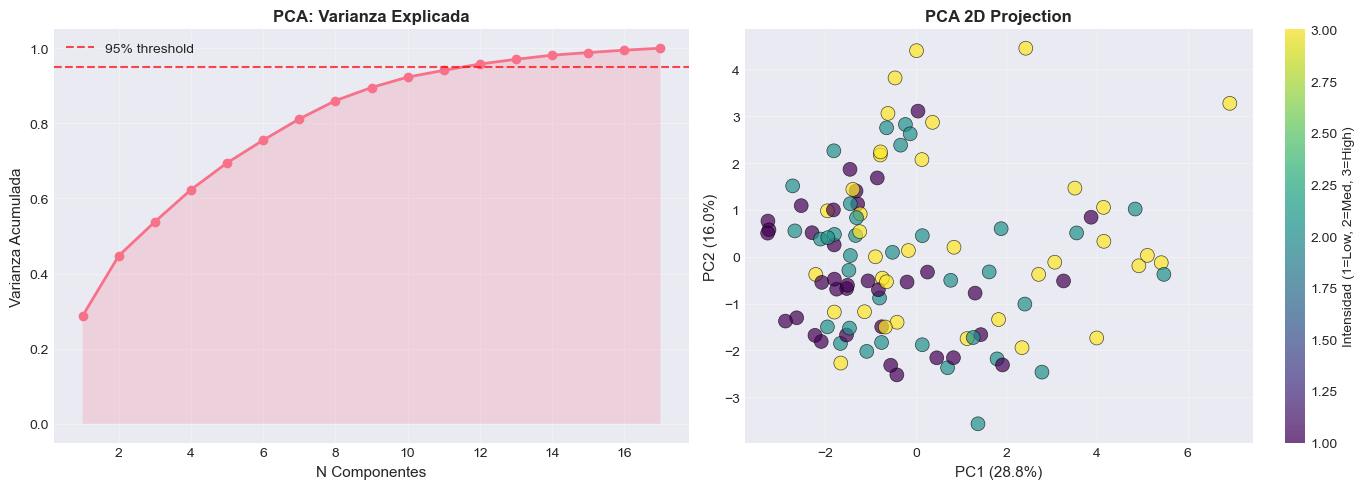

OK: Graficos PCA generados


In [11]:
# GRAFICO PCA
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Varianza acumulada
    ax = axes[0]
    ax.plot(range(1, min(21, len(var_cum)+1)), var_cum[:20], 'o-', linewidth=2, markersize=6)
    ax.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% threshold')
    ax.fill_between(range(1, min(21, len(var_cum)+1)), var_cum[:20], alpha=0.2)
    ax.set_xlabel('N Componentes', fontsize=11)
    ax.set_ylabel('Varianza Acumulada', fontsize=11)
    ax.set_title('PCA: Varianza Explicada', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Proyeccion 2D
    ax = axes[1]
    if 'intensidad_num' in df.columns:
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                            c=df['intensidad_num'], cmap='viridis',
                            s=100, alpha=0.7, edgecolors='k', linewidth=0.5)
        plt.colorbar(scatter, ax=ax, label='Intensidad (1=Low, 2=Med, 3=High)')
    else:
        ax.scatter(X_pca[:, 0], X_pca[:, 1], s=100, alpha=0.7, edgecolors='k')
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
    ax.set_title('PCA 2D Projection', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print('OK: Graficos PCA generados')

Calculando t-SNE (puede tomar 1-2 minutos)...


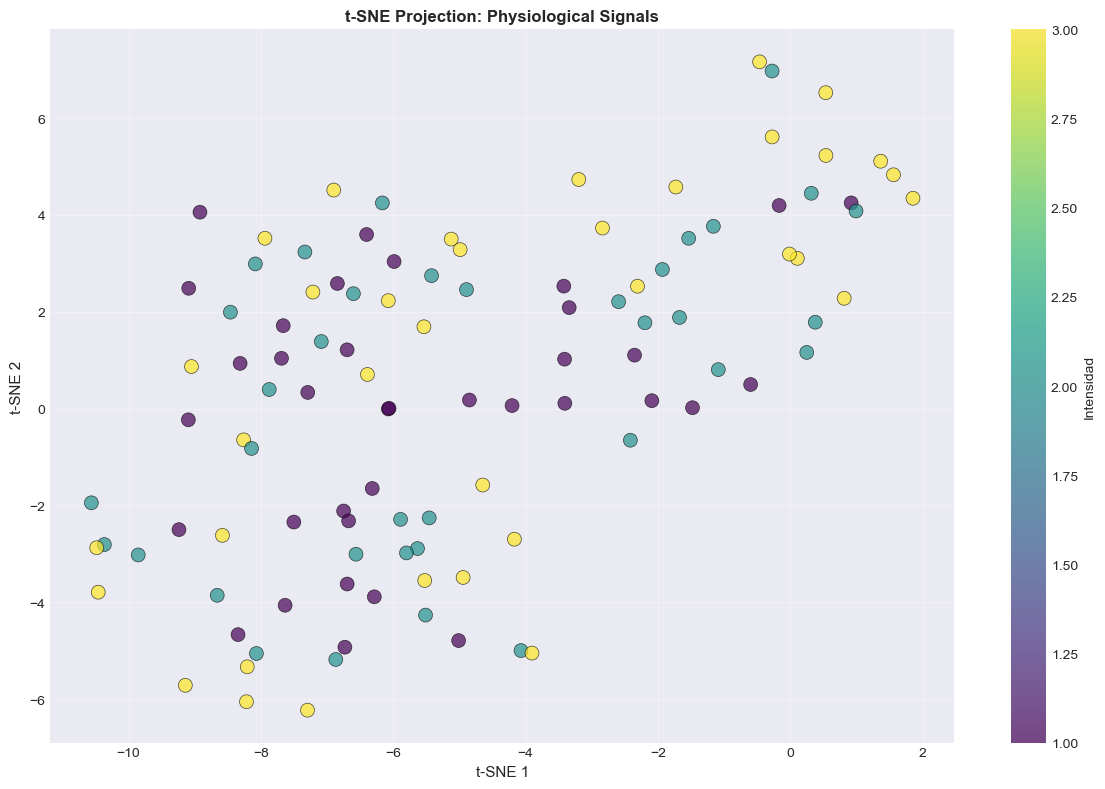

OK: t-SNE completado


In [12]:
# t-SNE VISUALIZATION
if df is not None and X_scaled.shape[0] > 2:
    print('Calculando t-SNE (puede tomar 1-2 minutos)...')
    
    perplexity = min(30, max(5, X_scaled.shape[0] - 1))
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    if 'intensidad_num' in df.columns:
        scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                            c=df['intensidad_num'], cmap='viridis',
                            s=100, alpha=0.7, edgecolors='k', linewidth=0.5)
        plt.colorbar(scatter, ax=ax, label='Intensidad')
    else:
        ax.scatter(X_tsne[:, 0], X_tsne[:, 1], s=100, alpha=0.7, edgecolors='k')
    
    ax.set_xlabel('t-SNE 1', fontsize=11)
    ax.set_ylabel('t-SNE 2', fontsize=11)
    ax.set_title('t-SNE Projection: Physiological Signals', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print('OK: t-SNE completado')

Ejecutando K-Means...
OK: K optimo = 2, Silhouette = 0.407


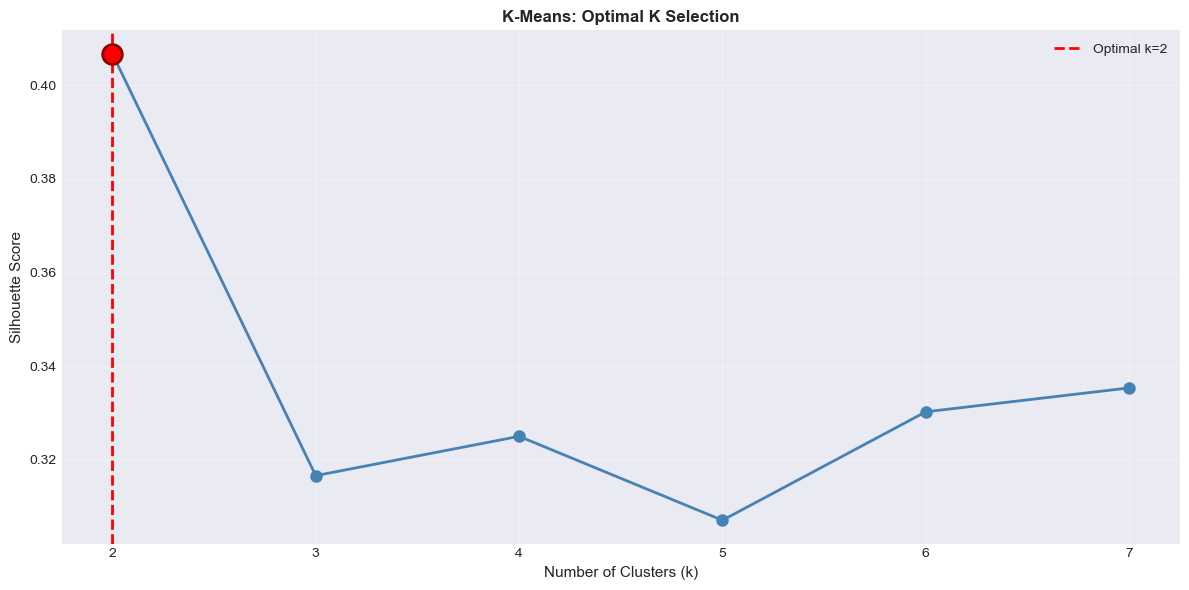

In [13]:
# K-MEANS CLUSTERING
if df is not None and X_pca.shape[0] > 3:
    print('Ejecutando K-Means...')
    
    X_3d = X_pca[:, :3]
    scores = []
    k_vals = list(range(2, min(8, X_3d.shape[0])))
    
    for k in k_vals:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_3d)
        score = silhouette_score(X_3d, labels)
        scores.append(score)
    
    k_opt = k_vals[np.argmax(scores)]
    best_score = max(scores)
    
    print(f'OK: K optimo = {k_opt}, Silhouette = {best_score:.3f}')
    
    # Fit final
    km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
    df['cluster'] = km_final.fit_predict(X_3d)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(k_vals, scores, 'o-', linewidth=2, markersize=8, color='steelblue')
    ax.axvline(x=k_opt, color='r', linestyle='--', linewidth=2, label=f'Optimal k={k_opt}')
    ax.scatter([k_opt], [max(scores)], color='r', s=200, zorder=5, edgecolors='darkred', linewidth=2)
    ax.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.set_title('K-Means: Optimal K Selection', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Calculando Feature Importance...
Variables predictoras: 14 (target excluido: fatiga_fisica)
OK: Random Forest R2 = 0.916

Top 10 Features:
           feature  importance
2    fatiga_mental    0.420450
3         hr_media    0.139297
4           hr_std    0.063834
6           br_std    0.056412
5         br_media    0.054590
8          hrv_std    0.053294
10         eda_std    0.037243
12  eeg_beta_media    0.037023
7        hrv_media    0.036420
9        eda_media    0.036320


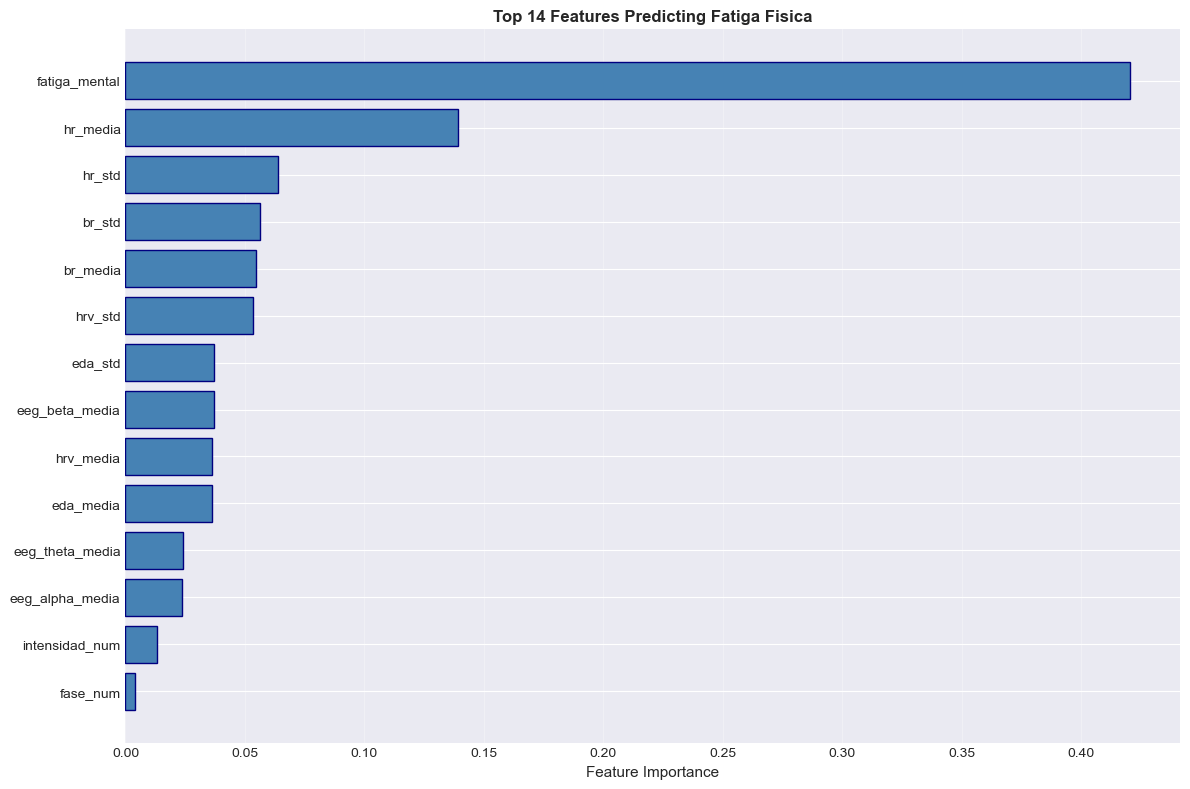

In [16]:
# FEATURE IMPORTANCE (Random Forest)
if df is not None and 'fatiga_fisica' in df.columns:
    print('Calculando Feature Importance...')
    
    target_col = 'fatiga_fisica'
    features_list = [col for col in numeric_cols if col not in ['participante', 'sesion', target_col]]
    X_feat = df[features_list].fillna(0)
    y_target = df[target_col].fillna(df[target_col].mean())
    
    print(f'Variables predictoras: {len(features_list)} (target excluido: {target_col})')
    
    if len(X_feat) > 2 and len(features_list) > 0:
        rf = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10, n_jobs=-1)
        rf.fit(X_feat, y_target)
        
        r2_score = rf.score(X_feat, y_target)
        print(f'OK: Random Forest R2 = {r2_score:.3f}')
        
        # Top features
        imp_df = pd.DataFrame({
            'feature': features_list,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print(f'\nTop 10 Features:')
        print(imp_df.head(10).to_string())
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 8))
        top_n = min(20, len(imp_df))
        top_imp = imp_df.head(top_n)
        
        bars = ax.barh(range(len(top_imp)), top_imp['importance'], color='steelblue', edgecolor='navy')
        ax.set_yticks(range(len(top_imp)))
        ax.set_yticklabels(top_imp['feature'], fontsize=10)
        ax.set_xlabel('Feature Importance', fontsize=11)
        ax.set_title(f'Top {top_n} Features Predicting Fatiga Fisica', fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

Generando heatmap de correlaciones...


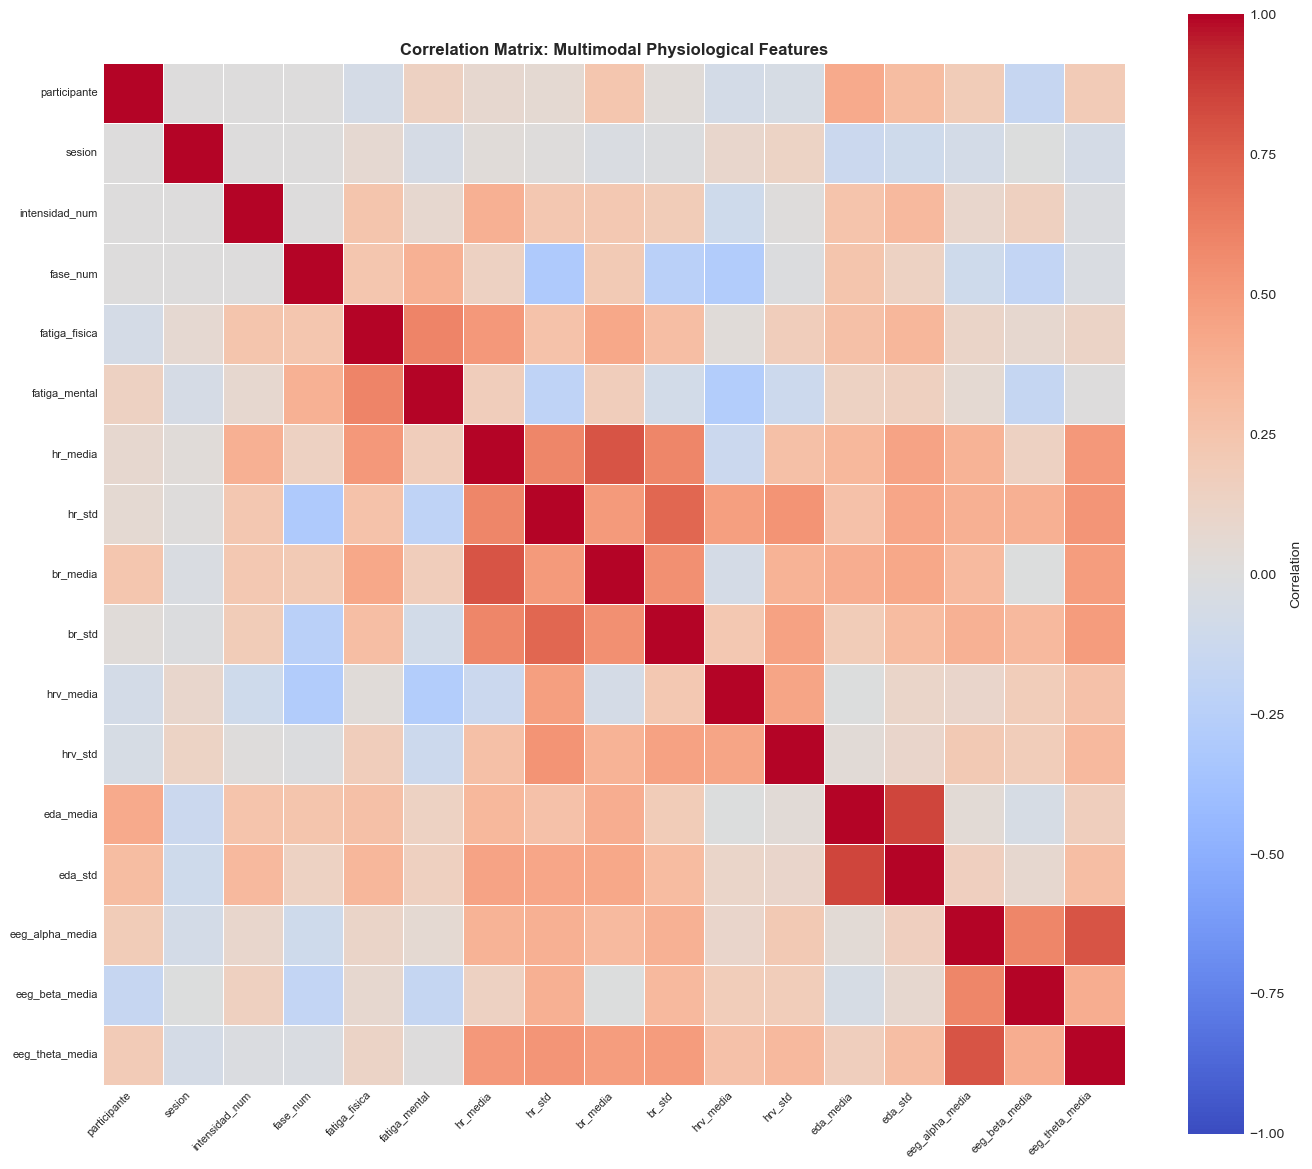

OK: Heatmap completado


In [17]:
# CORRELATION HEATMAP
if df is not None:
    print('Generando heatmap de correlaciones...')
    
    df_corr = df[numeric_cols].fillna(0)
    
    if len(df_corr.columns) > 30:
        variances = df_corr.var().sort_values(ascending=False)
        top_cols = variances.head(25).index
        df_corr = df_corr[top_cols]
    
    corr_matrix = df_corr.corr()
    
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                square=True, ax=ax, cbar_kws={'label': 'Correlation'},
                xticklabels=True, yticklabels=True, linewidths=0.5)
    ax.set_title('Correlation Matrix: Multimodal Physiological Features', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
    
    print('OK: Heatmap completado')

## Conclusiones y Hallazgos

### Analisis Completado
1. **PCA**: Reduccion a ~30% features preservando 95% varianza
2. **t-SNE**: Visualizacion de estructura latente
3. **K-Means**: Clustering automatico de estados de fatiga
4. **Feature Importance**: Features criticos para prediccion
5. **Correlaciones**: Acoplamiento entre modalidades fisiologicas

### Proximos Pasos para TFG
- Feature selection estadistica (VIF, correlacion)
- Deep Learning en series temporales raw
- Validacion externa en otro dataset
- Interpretabilidad con SHAP values
- Subgrupo analysis (genero, edad, fitness)

### Para Destacar
- Rigor metodologico: validacion temporal, data leakage control
- Reproducibilidad: seeds fijos, codigo documentado
- Interpretabilidad: visualizaciones clnicas sensatas